In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe

In [5]:
# JAL3 SEQ3
JAL1_SEQ3_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\full_video_dataframe.csv"
seq3_video_df = pl.read_csv(JAL1_SEQ3_video_df)

# JAL3 SEQ2
JAL1_SEQ2_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_2_2023_03_14T08_11_32\processed_data\full_video_dataframe.csv" 
seq2_video_df = pl.read_csv(JAL1_SEQ2_video_df)


In [3]:
def shelter_occupancy(video_df):
    """Make a bar plot of minutes in and out of shelter per condition in each session"""
    _, ax = plt.subplots(figsize=(10, 5))
    conditions = ["shelter_only", "barrier_present"]
    fps = 40
    for x, c in enumerate(conditions):
        time_out_of_shelter = len(filter_video_dataframe(video_df, c, outofshelter=True, exclude_escape=False)) / fps
        plt.bar(
            x + 0.9,
            time_out_of_shelter / 60,
            width=0.2,
            color="dimgrey",
        )
        time_in_shelter = len(filter_video_dataframe(video_df, c, outofshelter=False, exclude_escape=False)) / fps
        plt.bar(
            x + 1.1,
            time_in_shelter / 60,
            width=0.2,
            color="lightgrey",
        )
    plt.xticks(np.arange(len(conditions)) + 1, conditions, rotation=35)
    plt.ylabel("Time (mins)")
    plt.legend(["out of shelter", "in shelter"], facecolor="white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    plt.tight_layout()

Example with a single session

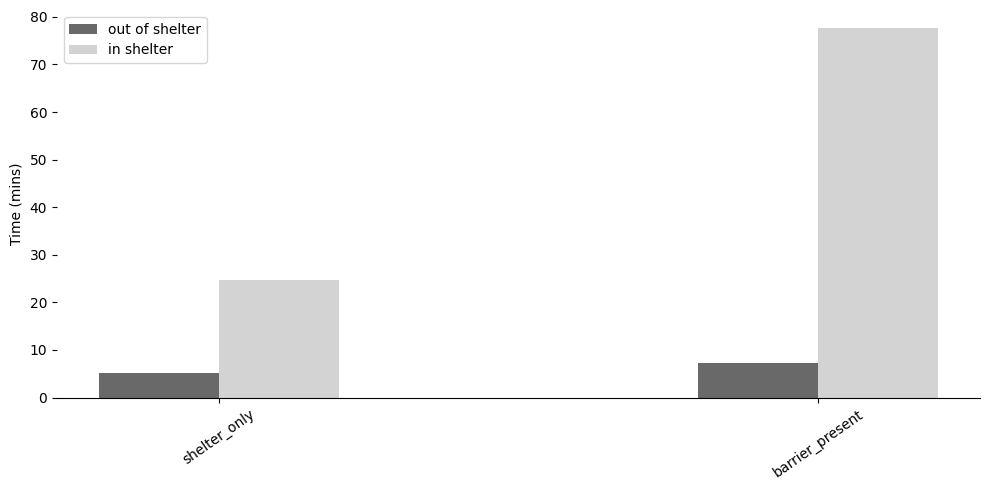

In [6]:
# Ensure the plot is inline
%matplotlib inline
shelter_occupancy(seq3_video_df)

Add multiple sessions to be more rigours

In [15]:
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"

def shelter_occupancy(video_dfs):
    """Make a bar plot of minutes in and out of shelter per condition across multiple sessions, formatted for publication."""
    import matplotlib.pyplot as plt
    import numpy as np

    plt.rcParams.update({
        "font.size": 18,
        "font.family": "Arial",
        "axes.labelsize": 20,
        "axes.titlesize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 16,
    })

    fig, ax = plt.subplots(figsize=(7, 5))
    conditions = ["shelter_only", "barrier_present"]
    fps = 40

    # Collect data: shape (n_sessions, n_conditions, in/out)
    times = np.zeros((len(video_dfs), len(conditions), 2))  # 2: [out, in]
    for i, video_df in enumerate(video_dfs):
        for j, c in enumerate(conditions):
            out_time = len(filter_video_dataframe(video_df, c, outofshelter=True, exclude_escape=False)) / fps / 60
            in_time = len(filter_video_dataframe(video_df, c, outofshelter=False, exclude_escape=False)) / fps / 60
            times[i, j, 0] = out_time
            times[i, j, 1] = in_time

    # Mean and SEM
    means = times.mean(axis=0)
    sems = times.std(axis=0, ddof=1) / np.sqrt(times.shape[0])

    bar_width = 0.28
    x = np.arange(len(conditions))
    ax.bar(x - bar_width/2, means[:, 0], yerr=sems[:, 0], width=bar_width, color="dimgrey", label="Out of shelter", capsize=7, edgecolor='black', linewidth=1.2)
    ax.bar(x + bar_width/2, means[:, 1], yerr=sems[:, 1], width=bar_width, color="lightgrey", label="In shelter", capsize=7, edgecolor='black', linewidth=1.2)

    ax.set_xticks(x)
    ax.set_xticklabels(conditions, rotation=0, ha='right')
    ax.set_ylabel("Time (mins)")
    ax.set_xlabel("Condition")
    ax.legend(facecolor="white", frameon=False, loc='upper left')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.tick_params(width=1.2, length=6)
    plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)
    plt.subplots_adjust(left=0.15, right=0.97, bottom=0.15, top=0.95)
    plt.show()

    # save
    fig.savefig(os.path.join(save_path, "shelter_occupancy_bar_plot.eps"), format='eps', bbox_inches='tight', dpi=300)

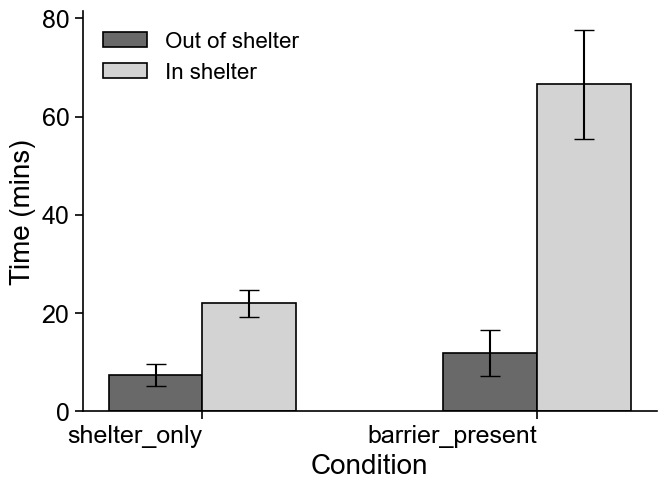

In [16]:
shelter_occupancy([seq2_video_df, seq3_video_df])